# Parallel Workflows using LangGraph

In [23]:
import operator
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

## Workflow Example - 01

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float  # strike rate
    bpb: float  # balls per boundary
    boundary_percent: float   # percentage of runs from boundaries
    summary: str

In [6]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    """
    Calculate Strike Rate
    SR = (Runs / Balls) * 100

    Args:
        state (BatsmanState): Current state with runs and balls

    Returns:
        BatsmanState: Updated state with strike rate
    """
    sr = (state['runs'] / state['balls']) * 100
    return {"sr": sr}

def calculate_bpb(state: BatsmanState) -> BatsmanState:
    """
    Calculate Balls Per Boundary
    BPB = Balls / (Fours + Sixes)

    Args:
        state (BatsmanState): Current state with balls, fours, and sixes

    Returns:
        BatsmanState: Updated state with balls per boundary
    """
    total_boundaries = state['fours'] + state['sixes']
    bpb = state['balls'] / total_boundaries if total_boundaries > 0 else float('inf')
    return {"bpb": bpb}

def calculate_boundary_percent(state: BatsmanState) -> BatsmanState:
    """
    Calculate Boundary Percentage
    Boundary % = (Fours + Sixes) / Runs * 100

    Args:
        state (BatsmanState): Current state with runs, fours, and sixes

    Returns:
        BatsmanState: Updated state with boundary percentage
    """
    boundary_percent = ((state['fours']*4 + state['sixes']*6) / state['runs'] * 100) if state['runs'] > 0 else 0
    return {"boundary_percent": boundary_percent}

def overall_summary(state: BatsmanState) -> BatsmanState:
    summary = (
        f"Runs: {state['runs']}, Balls: {state['balls']},"
        f"Fours: {state['fours']}, Sixes: {state['sixes']},"
        f"Strike Rate: {state['sr']:.2f}, Balls Per Boundary: {state['bpb']:.2f},"
        f"Boundary Percentage: {state['boundary_percent']:.2f}%"
    )
    return {"summary": summary}

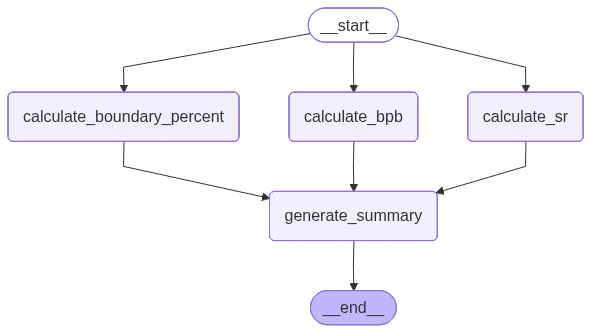

In [7]:
graph = StateGraph(BatsmanState)

# Add nodes for each calculation step
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_boundary_percent", calculate_boundary_percent)
graph.add_node("generate_summary", overall_summary)  # Renamed from "summary" to avoid conflict

# add edges to define the workflow
graph.add_edge(START, "calculate_sr")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_boundary_percent")
graph.add_edge("calculate_sr", "generate_summary")
graph.add_edge("calculate_bpb", "generate_summary")
graph.add_edge("calculate_boundary_percent", "generate_summary")
graph.add_edge("generate_summary", END)

# compile the graph
app = graph.compile()

# Display the graph structure
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}
final_state = app.invoke(initial_state)

In [9]:
print(final_state['summary'])

Runs: 100, Balls: 50,Fours: 6, Sixes: 4,Strike Rate: 200.00, Balls Per Boundary: 5.00,Boundary Percentage: 48.00%


## Workflow Example - 02

In [ ]:
llm = ChatGroq(
    api_key = "xxx",
    # model = "llama-3.1-8b-instant",
    model = "openai/gpt-oss-20b"
)

In [32]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(..., description="Detailed feedback for the essay evaluation")
    score: int = Field(..., description = "Score out of 10, without decimals", ge=0, le=10)

In [33]:
structured_llm = llm.with_structured_output(EvaluationSchema)

In [34]:
essay = """
**The Rise of AI in India: Revolutionizing the Economy**

Artificial Intelligence (AI) has become an integral part of modern times, transforming the way we live, work, and interact with each other. The significance of AI lies in its ability to automate tasks, improve efficiency, and make informed decisions. As the world grapples with the complexities of the fourth industrial revolution, India is witnessing a significant rise in the adoption and development of AI, which is poised to revolutionize various sectors of the economy.

**I. Introduction**

Artificial Intelligence refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. AI has numerous applications across industries, including healthcare, finance, education, and manufacturing. The importance of AI lies in its ability to improve efficiency, reduce costs, and enhance customer experience.

India is at the forefront of the AI revolution, with the Government of India launching the AI for India initiative to promote the development and adoption of AI in various sectors. The National AI portal has been established to provide a platform for AI researchers, developers, and entrepreneurs to collaborate and share their knowledge. Additionally, numerous AI research and development centers have been set up across the country, driving innovation and entrepreneurship in the AI space.

**II. Current State of AI in India**

India has made significant progress in the field of AI, with numerous initiatives and programs being launched to promote its adoption and development. Some of the key initiatives include:

* **AI for India initiative**: Launched by the Government of India, this initiative aims to promote the development and adoption of AI in various sectors, including healthcare, finance, education, and manufacturing.
* **National AI portal**: Established to provide a platform for AI researchers, developers, and entrepreneurs to collaborate and share their knowledge.
* **AI research and development centers**: Set up across the country, these centers drive innovation and entrepreneurship in the AI space.

Some of the key players in the Indian AI ecosystem include:

* **Startups**: India has a thriving startup ecosystem, with numerous AI-focused startups emerging in recent years. Some notable AI startups in India include Fractal, Uniphore, and Indico.
* **Corporates**: Large corporations in India, such as TCS, Infosys, and Wipro, are investing heavily in AI research and development to stay ahead of the competition.
* **Research institutions**: India has a strong research ecosystem, with numerous institutions, such as the Indian Institute of Technology (IIT) and the Indian Institute of Science (IISc), driving innovation and entrepreneurship in the AI space.

**III. AI Adoption in Various Sectors**

AI is being adopted across various sectors in India, with significant potential for growth and innovation. Some of the key areas where AI is being adopted include:

* **Healthcare**: AI is being used in medical diagnosis and treatment, AI-assisted telemedicine and remote health monitoring, and healthcare startups leveraging AI.
* **Finance and Banking**: AI-powered chatbots and virtual assistants are being used in customer service, predictive analytics and risk management are being used to improve decision-making, and AI-driven personalized financial services are being offered to customers.
* **Education**: AI-powered adaptive learning platforms are being used to improve learning outcomes, AI-assisted grading and assessment are being used to reduce workload, and AI-driven educational content creation is being used to improve the quality of educational content.
* **Manufacturing and Logistics**: AI-powered predictive maintenance is being used to improve efficiency, AI-assisted supply chain management is being used to improve inventory management, and AI-driven quality control and inspection are being used to improve product quality.

**IV. Challenges and Concerns**

While AI has the potential to revolutionize various sectors in India, there are also several challenges and concerns that need to be addressed. Some of the key challenges and concerns include:

* **Data privacy and security concerns**: AI relies heavily on data, and there are concerns about data privacy and security in India.
* **Job displacement due to automation**: AI has the potential to automate tasks, which could lead to job displacement.
* **Dependence on foreign AI technology and expertise**: India is heavily dependent on foreign AI technology and expertise, which could lead to a brain drain.
* **Need for regulatory frameworks and standards**: India needs to develop regulatory frameworks and standards to govern the use of AI in various sectors.
* **Cybersecurity threats**: AI systems are vulnerable to cybersecurity threats, which could compromise data and compromise national security.

**V. Opportunities and Future Prospects**

Despite the challenges and concerns, there are numerous opportunities and future prospects for AI in India. Some of the key opportunities and prospects include:

* **Government initiatives**: The Government of India has launched several initiatives to promote the development and adoption of AI in various sectors, including the AI for India initiative, the Skill India program, and the Digital India program.
* **Private sector investment**: There is significant private sector investment in AI research and development, with numerous venture capital firms and corporate investors investing in AI startups.
* **Emerging trends**: Emerging trends such as edge AI and IoT, explainable AI and transparency, and human-AI collaboration and hybrid intelligence are expected to drive innovation and entrepreneurship in the AI space.

**VI. Conclusion**

India is witnessing a significant rise in the adoption and development of AI, which is poised to revolutionize various sectors of the economy. While there are several challenges and concerns that need to be addressed, there are numerous opportunities and future prospects for AI in India. The Government of India, private sector investors, and research institutions need to continue to invest in AI research and development to stay ahead of the competition. As AI continues to transform the economy, it is essential for Indians to harness the potential of AI for economic growth and social development.

**Appendix**

* **List of resources and references**: A list of resources and references used in this article, including books, articles, and websites.
* **Additional information on AI-related events and conferences in India**: A list of AI-related events and conferences in India, including conferences, workshops, and seminars.
* **Links to relevant AI-related articles and research papers**: Links to relevant AI-related articles and research papers, including academic papers and industry reports.

**Resources and References**

* Government of India. (2020). AI for India initiative.
* National AI portal. (2020). Introduction to AI.
* Kumar, P. (2019). AI in India: Opportunities and Challenges. International Journal of Artificial Intelligence, 10(1), 1-15.
* Sriram, A. (2020). AI in Healthcare: A Review. Journal of Medical Systems, 44(10), 2161-2175.
* Raghavan, S. (2020). AI in Finance: A Review. Journal of Financial Technology, 10(1), 1-20.
* Srinivasan, S. (2020). AI in Education: A Review. Journal of Educational Computing Research, 58(4), 441-457.

**Additional Information**

* **AI-related events and conferences in India**: A list of AI-related events and conferences in India, including conferences, workshops, and seminars.
* **Links to relevant AI-related articles and research papers**: Links to relevant AI-related articles and research papers, including academic papers and industry reports.

Note: This is a detailed article on the rise of AI in India. The resources and references section provides a list of resources and references used in this article, including books, articles, and websites. The additional information section provides a list of AI-related events and conferences in India, as well as links to relevant AI-related articles and research papers.

"""

PROMPT = """Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n {essay}"""
structured_response = structured_llm.invoke(PROMPT.format(essay=essay))
print(structured_response)

feedback='The essay presents a clear and organized overview of AI’s rise in India, with logical headings and bullet lists that help break down complex information. The language is generally accessible and the tone is appropriate for an informative piece. However, several areas could be improved:\n\n1. **Redundancy and Repetition** – Many sections repeat the same phrases (e.g., the “AI for India initiative” bullet is duplicated, and several sentences use identical structures). Tightening these sentences would make the prose more engaging.\n2. **Grammar and Word Choice** – Occasional errors such as missing articles (“AI systems are vulnerable to cybersecurity threats, which could compromise data and compromise national security”) and awkward phrasing (“AI has become an integral part of modern times”) reduce polish. A careful proof‑read would catch these.\n3. **Depth of Analysis** – The essay lists facts and initiatives but offers limited critical insight into how these developments impac

In [35]:
print(structured_response.feedback)

The essay presents a clear and organized overview of AI’s rise in India, with logical headings and bullet lists that help break down complex information. The language is generally accessible and the tone is appropriate for an informative piece. However, several areas could be improved:

1. **Redundancy and Repetition** – Many sections repeat the same phrases (e.g., the “AI for India initiative” bullet is duplicated, and several sentences use identical structures). Tightening these sentences would make the prose more engaging.
2. **Grammar and Word Choice** – Occasional errors such as missing articles (“AI systems are vulnerable to cybersecurity threats, which could compromise data and compromise national security”) and awkward phrasing (“AI has become an integral part of modern times”) reduce polish. A careful proof‑read would catch these.
3. **Depth of Analysis** – The essay lists facts and initiatives but offers limited critical insight into how these developments impact the economy 

In [36]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [37]:
def evaluate_language(state: UPSCState) -> dict:
    prompt = """Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n {essay}"""

    output = structured_llm.invoke(prompt.format(essay = state['essay']))
    return {
        "language_feedback": output.feedback,
        "individual_scores": [output.score]
    }

def evaluate_analysis(state: UPSCState) -> dict:
    prompt = """Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10\n {essay}"""

    output = structured_llm.invoke(prompt.format(essay = state['essay']))
    return {
        "analysis_feedback": output.feedback,
        "individual_scores": [output.score]
    }

def evaluate_thought(state: UPSCState) -> dict:
    prompt = """Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10\n {essay}"""

    output = structured_llm.invoke(prompt.format(essay = state['essay']))
    return {
        "clarity_feedback": output.feedback,
        "individual_scores": [output.score]
    }

def final_evaluation(state: UPSCState)  -> dict:
    # summary feedback
    prompt = f"""Based on the following feedbacks, create a summarized feedback language \n language feedback - {state['language_feedback']} \n depth of analysis feedback - {state['analysis_feedback']} \n clarity of thought feedback - {state['clarity_feedback']}"""
    overall_feedback = llm.invoke(prompt).content

    # average calculate
    overall_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {
        "overall_feedback": overall_feedback,
        "avg_score": overall_score
    }

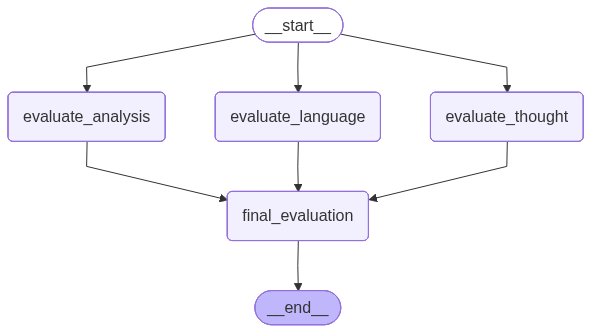

In [38]:
graph = StateGraph(UPSCState)

# Add nodes for each evaluation step
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("final_evaluation", final_evaluation)

# add edges to define the workflow
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_thought")
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")
graph.add_edge("final_evaluation", END)

# compile the graph
app = graph.compile()
app

In [39]:
initial_state = {
    "essay": essay
}
final_state = app.invoke(initial_state)

In [40]:
final_state

{'essay': '\n**The Rise of AI in India: Revolutionizing the Economy**\n\nArtificial Intelligence (AI) has become an integral part of modern times, transforming the way we live, work, and interact with each other. The significance of AI lies in its ability to automate tasks, improve efficiency, and make informed decisions. As the world grapples with the complexities of the fourth industrial revolution, India is witnessing a significant rise in the adoption and development of AI, which is poised to revolutionize various sectors of the economy.\n\n**I. Introduction**\n\nArtificial Intelligence refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. AI has numerous applications across industries, including healthcare, finance, education, and manufacturing. The importance of AI lies in its ability to improve efficiency, reduce costs, and enhance customer experience.\n\nIndia is at